In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import json
import warnings
warnings.filterwarnings('ignore')

In [2]:
feature_dir = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/feature_tensors")
plots_dir   = Path("/Users/rahulravi23/Desktop/Work/seismic_hazard_modelling/seismic_hazard_modelling/data/plots")

with open(feature_dir / "feature_names.json") as f:
    feature_names = json.load(f)

PATCHES = [
    "Kanto_Japan", "Tohoku_Japan", "Central_Chile", "Central_Turkey",
    "Central_Nepal", "North_Island_NZ", "Sumatra", "Kutch_India",
    "Sichuan_China", "W_Australia", "S_Norway", "Ordos_China"
]

REGIME_LABELS = {
    "Kanto_Japan":     "Subduction",
    "Tohoku_Japan":    "Subduction",
    "Central_Chile":   "Megathrust",
    "Central_Turkey":  "Strike-slip",
    "Central_Nepal":   "Collision",
    "North_Island_NZ": "Subduction",
    "Sumatra":         "Subduction",
    "Kutch_India":     "Intraplate",
    "Sichuan_China":   "Collision",
    "W_Australia":     "Craton",
    "S_Norway":        "Post-glacial",
    "Ordos_China":     "Craton",
}

REGIME_COLORS = {
    "Subduction":   "#2196F3",
    "Megathrust":   "#00BCD4",
    "Strike-slip":  "#FF5722",
    "Collision":    "#9C27B0",
    "Intraplate":   "#FF9800",
    "Craton":       "#4CAF50",
    "Post-glacial": "#795548",
}

# Exclude categorical/circular features from PCA and correlation
# Use only continuous normalised features
CONTINUOUS_FEATURES = [
    'vs30', 'elevation', 'slope', 'roughness',
    'sediment_km', 'crustal_km', 'dist_fault_km',
    'fault_density', 'heat_flow'
]
cont_idx = [feature_names.index(f) for f in CONTINUOUS_FEATURES]

Total valid cells: 11,004 across 12 patches

Computing correlation matrix...


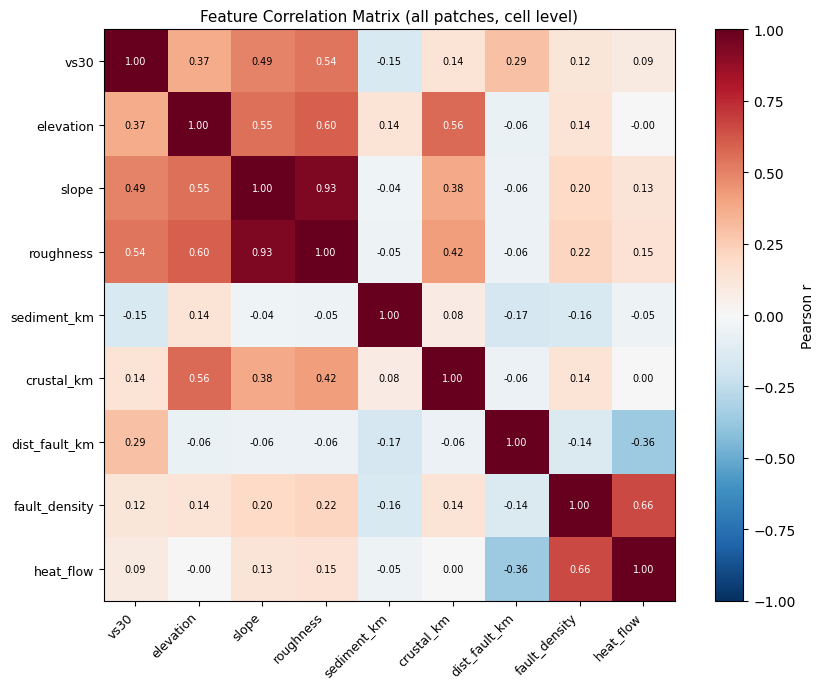

Saved correlation_matrix.png

Running PCA...
Explained variance per component:
  PC1: 35.4%  (cumulative: 35.4%)
  PC2: 19.3%  (cumulative: 54.7%)
  PC3: 15.6%  (cumulative: 70.3%)
  PC4: 8.9%  (cumulative: 79.2%)

PC loadings (feature contributions):
                 PC1    PC2    PC3    PC4
vs30           0.367 -0.168 -0.394 -0.448
elevation      0.424 -0.166  0.249  0.160
slope          0.496 -0.080 -0.011 -0.077
roughness      0.518 -0.080 -0.015 -0.068
sediment_km   -0.027 -0.099  0.686 -0.632
crustal_km     0.312 -0.101  0.289  0.552
dist_fault_km -0.032 -0.370 -0.456 -0.122
fault_density  0.222  0.589 -0.137  0.040
heat_flow      0.152  0.653 -0.027 -0.208


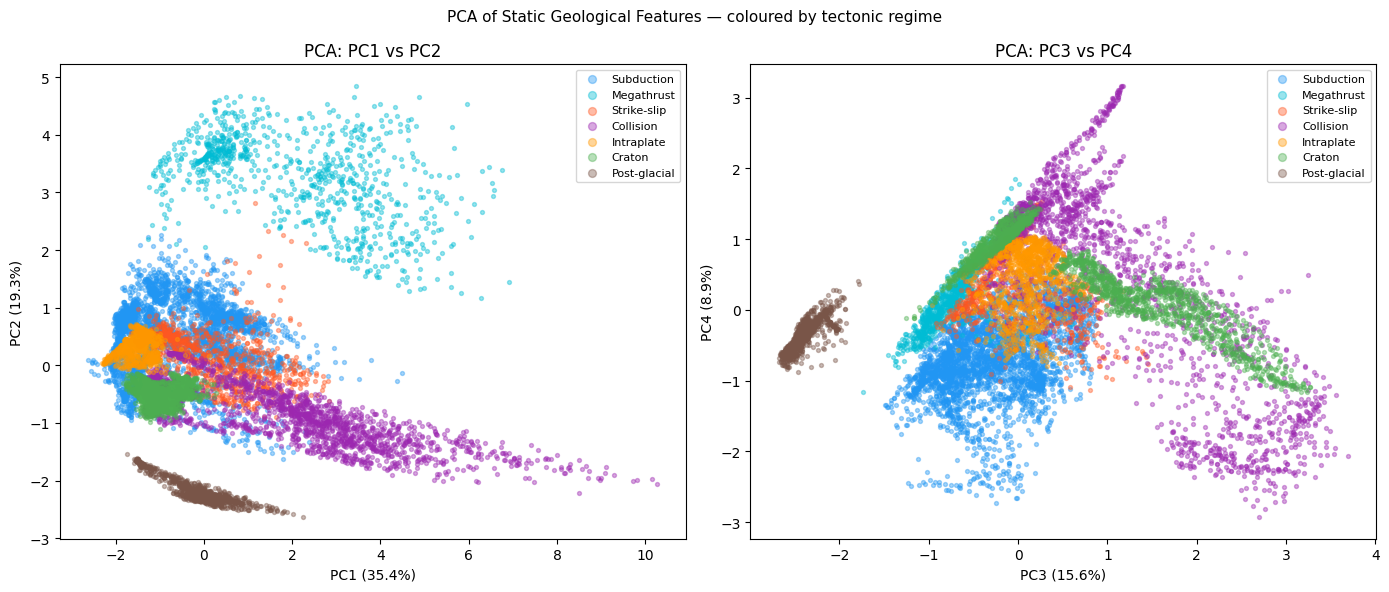

Saved pca_regimes.png

Running silhouette analysis (k=2 to 16)...
  k= 2  silhouette=0.3864  inertia=74534.9
  k= 3  silhouette=0.3721  inertia=61120.2
  k= 4  silhouette=0.4101  inertia=49542.3
  k= 5  silhouette=0.3550  inertia=41950.8
  k= 6  silhouette=0.3375  inertia=35591.8
  k= 7  silhouette=0.3490  inertia=32172.0
  k= 8  silhouette=0.2993  inertia=29317.3
  k= 9  silhouette=0.3074  inertia=26879.2
  k=10  silhouette=0.3694  inertia=24656.3
  k=11  silhouette=0.3242  inertia=22945.6
  k=12  silhouette=0.3215  inertia=21250.4
  k=13  silhouette=0.3507  inertia=19814.0
  k=14  silhouette=0.3570  inertia=18315.3
  k=15  silhouette=0.3639  inertia=17274.5
  k=16  silhouette=0.3636  inertia=16340.8


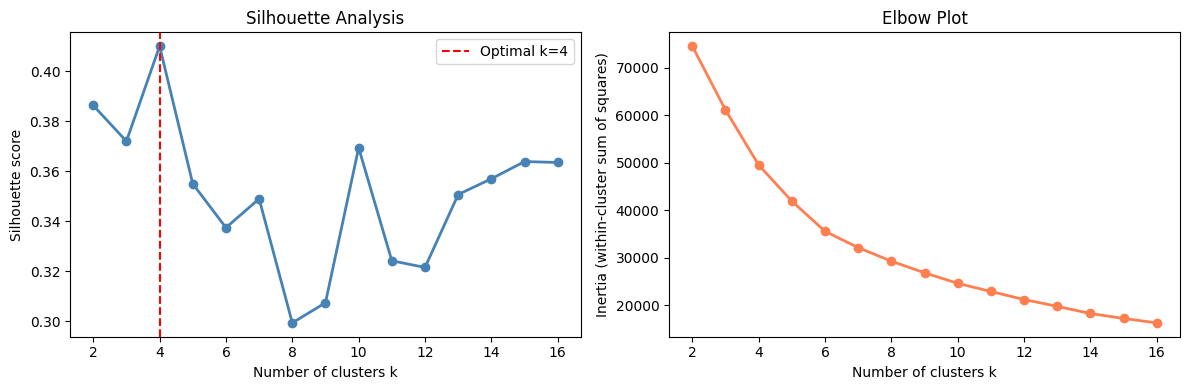


Optimal k = 4 (silhouette = 0.4101)
Saved silhouette_elbow.png


In [3]:
print("Collecting feature vectors across all patches...")
all_vectors  = []
all_patch    = []
all_regime   = []

for patch_name in PATCHES:
    t    = np.load(feature_dir / f"{patch_name}_features.npy")
    lons = np.load(feature_dir / f"{patch_name}_lons.npy")
    lats = np.load(feature_dir / f"{patch_name}_lats.npy")

    n_lat, n_lon, n_feat = t.shape
    for i in range(n_lat):
        for j in range(n_lon):
            vec = t[i, j, cont_idx]
            if not np.any(np.isnan(vec)):
                all_vectors.append(vec)
                all_patch.append(patch_name)
                all_regime.append(REGIME_LABELS[patch_name])

X       = np.array(all_vectors)   # (N_cells, 9)
patches = np.array(all_patch)
regimes = np.array(all_regime)
print(f"Total valid cells: {len(X):,} across {len(PATCHES)} patches")

# ── 1. Correlation matrix ─────────────────────────────────────────────────────
print("\nComputing correlation matrix...")
corr = np.corrcoef(X.T)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(CONTINUOUS_FEATURES)))
ax.set_yticks(range(len(CONTINUOUS_FEATURES)))
ax.set_xticklabels(CONTINUOUS_FEATURES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(CONTINUOUS_FEATURES, fontsize=9)
plt.colorbar(im, ax=ax, label='Pearson r')
# Annotate cells
for i in range(len(CONTINUOUS_FEATURES)):
    for j in range(len(CONTINUOUS_FEATURES)):
        ax.text(j, i, f"{corr[i,j]:.2f}", ha='center', va='center',
                fontsize=7, color='white' if abs(corr[i,j]) > 0.5 else 'black')
ax.set_title("Feature Correlation Matrix (all patches, cell level)", fontsize=11)
plt.tight_layout()
plt.savefig(plots_dir / "correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved correlation_matrix.png")

# ── 2. PCA ────────────────────────────────────────────────────────────────────
print("\nRunning PCA...")
pca   = PCA(n_components=4)
X_pca = pca.fit_transform(X)

print("Explained variance per component:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev*100:.1f}%  (cumulative: {sum(pca.explained_variance_ratio_[:i+1])*100:.1f}%)")

print("\nPC loadings (feature contributions):")
loading_df = pd.DataFrame(
    pca.components_.T,
    index=CONTINUOUS_FEATURES,
    columns=[f"PC{i+1}" for i in range(4)]
).round(3)
print(loading_df.to_string())

# PCA plot — colour by regime
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (2, 3)]):
    for regime, color in REGIME_COLORS.items():
        mask = regimes == regime
        if mask.sum() == 0:
            continue
        ax.scatter(
            X_pca[mask, pc_x], X_pca[mask, pc_y],
            c=color, label=regime, alpha=0.4, s=8
        )
    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]*100:.1f}%)")
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]*100:.1f}%)")
    ax.set_title(f"PCA: PC{pc_x+1} vs PC{pc_y+1}")
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle("PCA of Static Geological Features — coloured by tectonic regime",
             fontsize=11)
plt.tight_layout()
plt.savefig(plots_dir / "pca_regimes.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved pca_regimes.png")

# ── 3. Silhouette analysis ────────────────────────────────────────────────────
print("\nRunning silhouette analysis (k=2 to 16)...")
sil_scores = []
inertias   = []
k_range    = range(2, 17)

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X)
    sil = silhouette_score(X, lbl, sample_size=min(5000, len(X)))
    sil_scores.append(sil)
    inertias.append(km.inertia_)
    print(f"  k={k:>2}  silhouette={sil:.4f}  inertia={km.inertia_:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), sil_scores, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Silhouette score")
axes[0].set_title("Silhouette Analysis")
axes[0].axvline(x=k_range[np.argmax(sil_scores)], color='red',
                linestyle='--', label=f"Optimal k={k_range[np.argmax(sil_scores)]}")
axes[0].legend()

axes[1].plot(list(k_range), inertias, 'o-', color='coral', linewidth=2)
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Inertia (within-cluster sum of squares)")
axes[1].set_title("Elbow Plot")

plt.tight_layout()
plt.savefig(plots_dir / "silhouette_elbow.png", dpi=150, bbox_inches='tight')
plt.show()

optimal_k = list(k_range)[np.argmax(sil_scores)]
print(f"\nOptimal k = {optimal_k} (silhouette = {max(sil_scores):.4f})")
print("Saved silhouette_elbow.png")

## Insights

### Overview

<p>Following rasterisation of all seven static layers to a common 0.1° grid, features were stacked into a unified per-patch feature tensor and subjected to three cross-layer EDA checks: a correlation matrix to verify physically expected relationships between features, a PCA to assess regime separability in the combined feature space, and a silhouette analysis to determine the optimal number of geological clusters for the frozen prior. These checks collectively serve as the validation gate before GMM clustering — if the feature space did not show meaningful geological structure at this stage, the frozen prior argument would be unsupportable.</p>

### Feature Tensor Construction

<p>Twelve features were stacked per patch into tensors of shape (n_lat, n_lon, 12): vs30, elevation, slope, roughness, sediment_km, crustal_km, dist_fault_km, fault_density, fault_slip, heat_flow, stress_azi, and stress_regime. The three continuous categorical or circular features (fault_slip, stress_azi, stress_regime) were excluded from PCA, correlation analysis, and clustering, leaving nine continuous features for all quantitative analysis. Global standardisation was applied across all patches simultaneously — subtracting the global mean and dividing by global standard deviation computed from all valid cells across all 12 patches. This ensures that the same scale is used everywhere and that feature values are directly comparable across patches, which is a prerequisite for cross-regional transfer.</p>

<p>NaN cells in each tensor correspond entirely to ocean coverage — Tohoku (44.2%), Kanto (26.4%), Norway (20.0%), and Sumatra (11.0%) are the most affected, reflecting their significant offshore fractions. All other patches are 0% NaN, confirming complete land coverage. NaN cells are excluded from all EDA analyses and will be masked during GNN graph construction.</p>

### Correlation Matrix Findings

<p>The correlation matrix computed across all valid cells from all 12 patches reveals a set of physically interpretable relationships that serve as independent validation of data quality. Slope and roughness show near-perfect correlation (r=0.93), expected since roughness is derived from elevation gradients — these two features are partially redundant but retained because they capture different aspects of terrain texture at the 0.1° scale. Fault density and heat flow are strongly positively correlated (r=0.66), reflecting the co-occurrence of dense fault networks and elevated crustal heat production in tectonically active regions — a geomechanically meaningful relationship that confirms both layers are capturing real tectonic signal rather than noise. Distance to fault and heat flow are negatively correlated (r=-0.36), consistent with the physical expectation that proximity to active fault systems is associated with elevated heat flow from friction and fluid circulation.</p>

<p>The Vs30/sediment anticorrelation (r=-0.15) is present but weaker than expected from the theoretical relationship between sediment thickness and shear wave velocity. This reflects the cross-patch nature of the correlation — the global dataset mixes geological settings where the relationship holds strongly (e.g. Ordos thick sediment / low Vs30) with settings where it is confounded by other factors (e.g. Norway hard rock with both low sediment and moderate Vs30 due to slope-proxy limitations). Within individual patches the anticorrelation is expected to be stronger, and the presence of even a weak global signal confirms the two layers are not independent.</p>

<p>Elevation and crustal thickness are moderately correlated (r=0.56), reflecting the isostatic relationship between surface topography and crustal thickness — high mountains require thick crustal roots for isostatic support. This is particularly visible in the Nepal and Sichuan patches where both features reach their maximum values simultaneously.</p>

### PCA Findings

<p>PCA on the nine continuous features explains 35.4%, 19.3%, 15.6%, and 8.9% of variance in PC1–PC4 respectively, with 79.2% cumulative variance explained by four components. This is a strong result — four interpretable dimensions capture nearly 80% of the total geological variability across 12 globally distributed patches, confirming that the feature space has low intrinsic dimensionality consistent with a small number of underlying geological regime types.</p>

<p>PC1 (35.4%) is a topographic relief and crustal thickness axis, dominated by roughness (0.518), slope (0.496), elevation (0.424), Vs30 (0.367), and crustal thickness (0.312). High PC1 values correspond to geologically active, mountainous, thick-crustal settings; low values correspond to flat, thin-crusted, or low-relief terrain. PC2 (19.3%) is a tectonic activity axis, dominated by heat flow (0.653) and fault density (0.589) with negative dist_fault_km (-0.370). High PC2 values correspond to thermally active, fault-dense regions; low values correspond to cold, fault-distant stable settings. PC3 (15.6%) separates thick-sediment basin settings (positive sediment, 0.686) from fault-proximal thin-sediment environments (negative dist_fault, -0.456). PC4 (8.9%) captures the crustal thickness versus sediment thickness tradeoff, distinguishing deep cratonic crust with thin sediment from moderate-depth crust with thick sediment cover.</p>

<p>The PC1-PC2 plot reveals clear and physically interpretable regime separation. Collision patches (Nepal, Sichuan — purple) form a distinctive elongated cluster extending to PC1=10, driven by extreme elevation, slope, roughness, and crustal thickness. No other regime occupies this region of feature space — the Himalayan and Tibetan geological signatures are unique and unambiguous. Megathrust Chile (cyan) sits isolated in the upper left quadrant with high PC2 (high heat flow, dense faults) and moderate PC1 (Andean terrain), clearly distinct from the subduction patches despite sharing a convergent tectonic setting. Post-glacial Norway (brown) is completely isolated at strongly negative PC2 — the combination of cold Baltic Shield lithosphere, zero fault density, and hard rock Vs30 produces a feature signature that no other patch approaches. Stable craton patches (Australia and Ordos — green) cluster tightly together in the centre-left despite being on different continents, confirming that the feature space is capturing geological regime rather than geographic proximity. This is the single most important validation result in the EDA: two patches from completely different parts of the world occupy the same region of feature space because they share the same geological character.</p>

<p>Subduction patches (blue — Japan, NZ, Sumatra) show the most internal spread, reflecting the genuine diversity within the subduction regime — the Kanto dual-subduction interface, the Hikurangi-TVZ NZ system, and the Sunda subduction are geologically distinct despite sharing the same broad tectonic classification. This spread is acceptable and expected; the GNN will learn to distinguish within-regime variation through the temporal dynamics, while the frozen prior provides the broad regime context. Intraplate Kutch (orange) occupies a distinct intermediate position, separated from both the active margins and the stable cratons, correctly reflecting its reactivated Precambrian rift character.</p>

### Silhouette & Elbow Analysis

<p>The silhouette analysis identifies k=4 as the statistically optimal cluster count (silhouette score 0.41), with a secondary local maximum at k=10 (silhouette score 0.37). The elbow plot shows a clear inflection at k=4–5 with gradual flattening beyond k=8, consistent with the silhouette result. The k=4 optimum corresponds to four natural geological groupings visible in the PCA: high-relief collision and plateau settings, active tectonic margins (subduction, megathrust, strike-slip), stable cratonic interiors, and the post-glacial/rebound outlier. These four groupings align closely with first-order tectonic regime classifications, providing independent statistical validation that the feature space is recovering real geological structure rather than arbitrary data clusters.</p>

<p>The secondary peak at k=10 suggests that finer subdivision within these broad classes is also statistically supported — for example, separating the Himalayan collision from the Tibetan plateau, or distinguishing the Japan subduction interface from the back-arc NZ setting. This finding directly motivates the cluster resolution ablation (Ablation A in the evaluation framework): k=4 will be used as the coarse prior and k=8–10 as the fine prior, with transfer AUC compared across both settings to quantify how much the prior resolution matters for generalisation performance.</p>

<p>The overall picture from the EDA is unambiguous: the combined static feature space contains rich, physically interpretable geological structure that is well-suited to unsupervised regime clustering. The separation observed in PCA space — particularly the isolation of the collision, post-glacial, and craton regimes — provides strong prior evidence that a frozen GMM prior trained on these features will assign meaningful and transferable regime labels to unseen patches, supporting the central architectural claim of the project.</p>